# Per-LD-block SNP and SV density audit

**Question.** In how many hapFIRE LD blocks is SV evidence proportionally significant relative to SNP evidence? Does the "block that's just an SV" thought experiment — where SV k-mers should dominate `h_block` estimation — actually occur in the data?

**Why this matters.** Two strategic implications:

1. If SV-dominated blocks are common, then a method that incorporates SV k-mer evidence into per-block `h` estimation (cactus_em) has a structural advantage over hapFIRE-projection (HARP is per-base SNP-only — invisible to SV k-mers).
2. If they're rare, then hapFIRE-projection on a denser SNP panel + per-block `h` is sufficient, and cactus_em's joint EM doesn't add load-bearing capability.

**Setup.** For each of 12,109 LD blocks (built by hapFIRE's BigLD on xwu's 3.2M-SNP panel at r²=0.5), count:
- `n_snp_xwu`: SNPs in xwu's GrENE-Net panel — what hapFIRE currently sees.
- `n_snp_dense`: SNPs in xwu ∪ cactus pangenome positions — what a dense-panel re-run would see.
- `n_sv`: SVs from the **production 231-founder panel** (cactus 80 long-read + Beagle-imputed 151, the panel used by `cn_var_231_v2`), filtered to `|alt_len − ref_len| ≥ 50`. **184,663 SVs total.**
- `sv_kmer_share`: SV evidence fraction of total k-mer mass in the block (assuming ~32 k-mers per SV from PanGenie's per-allele cap, ~1 per SNP).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    '/carnegie/nobackup/scratch/tbellagio/hapfire_sv/results/blocks_snp_sv_density.tsv.gz',
    sep='\t')
df['sv_kmer_share'] = (32 * df.n_sv) / (df.n_snp_xwu + 32 * df.n_sv).clip(lower=1)
df['sv_kmer_share_dense'] = (32 * df.n_sv) / (df.n_snp_dense + 32 * df.n_sv).clip(lower=1)
print(f'n_blocks = {len(df):,}')
df.head()

n_blocks = 12,109


,chrom,pos_start,pos_end,bp_len,n_snp_xwu,n_snp_xwu_recount,n_snp_dense,n_snp_cactus_only,n_sv,n_uniq_haps_xwu,sv_kmer_share,sv_kmer_share_dense
0,Chr1,291,7468,7178,169,169,298,129,0,84,0.000000,0.000000
1,Chr1,7572,142940,135369,2799,2799,4874,2075,114,219,0.565845,0.428069
2,Chr1,142971,143272,302,7,7,10,3,0,8,0.000000,0.000000
3,Chr1,143366,144872,1507,40,40,65,25,0,50,0.000000,0.000000
4,Chr1,144922,146471,1550,33,33,46,13,1,41,0.492308,0.410256


## Headline numbers

In [2]:
summary = pd.DataFrame({
    'metric': [
        'Total blocks',
        'Total bp covered (Mb)',
        'Total xwu SNPs in blocks',
        'Total dense-panel SNPs in blocks',
        'Cactus-only SNP extras',
        'Total SVs in blocks',
        'Blocks with ≥1 SV',
    ],
    'value': [
        f'{len(df):,}',
        f'{df.bp_len.sum()/1e6:,.1f}',
        f'{df.n_snp_xwu.sum():,}',
        f'{df.n_snp_dense.sum():,}',
        f'{df.n_snp_cactus_only.sum():,} (+{df.n_snp_cactus_only.sum()/df.n_snp_xwu.sum()*100:.0f}% over xwu)',
        f'{df.n_sv.sum():,}',
        f'{(df.n_sv >= 1).sum():,} ({(df.n_sv >= 1).mean()*100:.1f}%)',
    ],
})
summary

,metric,value
0,Total blocks,"12,109"
1,Total bp covered (Mb),118.1
2,Total xwu SNPs in blocks,"3,235,480"
3,Total dense-panel SNPs in blocks,"6,012,347"
4,Cactus-only SNP extras,"2,776,867 (+86% over xwu)"
5,Total SVs in blocks,"182,945"
6,Blocks with ≥1 SV,"5,027 (41.5%)"


In [3]:
# Per-block distribution percentiles
qs = [0, 5, 25, 50, 75, 95, 99, 100]
dist = pd.DataFrame({
    'percentile': qs,
    'n_snp_xwu':   [int(np.percentile(df.n_snp_xwu, q)) for q in qs],
    'n_snp_dense': [int(np.percentile(df.n_snp_dense, q)) for q in qs],
    'n_sv':        [int(np.percentile(df.n_sv, q)) for q in qs],
    'bp_len':      [int(np.percentile(df.bp_len, q)) for q in qs],
})
dist

,percentile,n_snp_xwu,n_snp_dense,n_sv,bp_len
0,0,7,7,0,14
1,5,8,11,0,145
2,25,17,25,0,422
3,50,34,55,0,1031
4,75,99,171,3,3345
5,95,1423,2514,82,52523
6,99,4171,7593,269,167785
7,100,28357,67472,1798,748248


## Joint distribution: SNPs × SVs per block

What we want to see: the lower-left quadrant (few SNPs, ≥1 SV) is where SV evidence is most informative for `h_block`. The upper-right (many SNPs, many SVs) is where SNPs dominate and SVs add little to `h_block`.

In [4]:
snp_bins = [-1, 0, 9, 99, 999, 1e9]
snp_lab = ['0', '1-10', '11-100', '101-1000', '>1000']
sv_bins = [-1, 0, 4, 19, 1e9]
sv_lab = ['0', '1-5', '6-20', '>20']

df['snp_xwu_bin']   = pd.cut(df.n_snp_xwu,   bins=snp_bins, labels=snp_lab)
df['snp_dense_bin'] = pd.cut(df.n_snp_dense, bins=snp_bins, labels=snp_lab)
df['sv_bin']        = pd.cut(df.n_sv,        bins=sv_bins,  labels=sv_lab)

ct_xwu = pd.crosstab(df.snp_xwu_bin,   df.sv_bin, margins=True)
ct_den = pd.crosstab(df.snp_dense_bin, df.sv_bin, margins=True)
print('=== xwu panel (what hapFIRE currently uses) ===')
print(ct_xwu.to_string())
print()
print('=== dense panel (xwu ∪ cactus SNPs) ===')
print(ct_den.to_string())

=== xwu panel (what hapFIRE currently uses) ===
sv_bin          0   1-5  6-20   >20    All
snp_xwu_bin                               
1-10          822    62    14    12    910
11-100       5718  1614   551   289   8172
101-1000      480   586   587   568   2221
>1000          62     5    36   703    806
All          7082  2267  1188  1572  12109

=== dense panel (xwu ∪ cactus SNPs) ===
sv_bin            0   1-5  6-20   >20    All
snp_dense_bin                               
1-10            285     9     0     2    296
11-100         5814  1303   334   136   7587
101-1000        865   945   764   550   3124
>1000           118    10    90   884   1102
All            7082  2267  1188  1572  12109


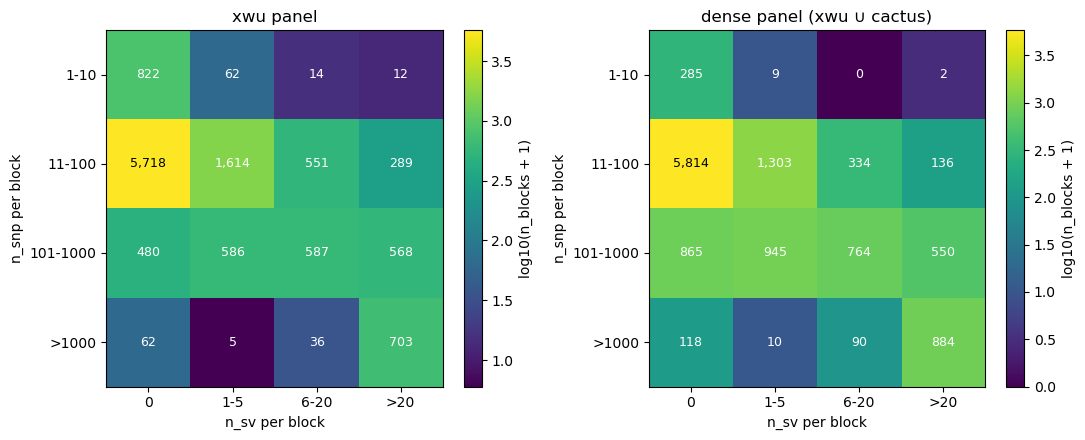

In [5]:
# Visualize as heatmaps (counts in log scale for visibility)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, ct, title in [
    (axes[0], ct_xwu.iloc[:-1, :-1].astype(float), 'xwu panel'),
    (axes[1], ct_den.iloc[:-1, :-1].astype(float), 'dense panel (xwu ∪ cactus)'),
]:
    arr = ct.values
    im = ax.imshow(np.log10(arr + 1), cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(ct.columns)));   ax.set_xticklabels(ct.columns)
    ax.set_yticks(range(len(ct.index)));     ax.set_yticklabels(ct.index)
    ax.set_xlabel('n_sv per block')
    ax.set_ylabel('n_snp per block')
    ax.set_title(title)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            ax.text(j, i, f'{int(arr[i,j]):,}', ha='center', va='center',
                    color='white' if arr[i,j] < arr.max()/3 else 'black', fontsize=9)
    plt.colorbar(im, ax=ax, label='log10(n_blocks + 1)')
plt.tight_layout()
plt.savefig('/carnegie/nobackup/scratch/tbellagio/hapfire_sv/plots/blocks_snp_sv_heatmap.png',
            dpi=110, bbox_inches='tight')
plt.show()

## SV-evidence share of total k-mer mass per block

Approximation: each SNP contributes ~1 k-mer to the EM, each SV bubble contributes ~32 k-mers (PanGenie's per-allele cap × 2 alleles). The fraction:
$$\text{sv\_share}(b) = \frac{32 \cdot n_{sv}(b)}{n_{snp}(b) + 32 \cdot n_{sv}(b)}$$

Blocks where this is high are where SV k-mers materially constrain `h_block` — i.e., the regime where joint-EM with SV evidence beats pure SNP-projection.

In [6]:
thresholds = [0.10, 0.30, 0.50, 0.70, 0.90, 1.00]
rows = []
for t in thresholds:
    rows.append({
        'threshold': t,
        'xwu_n_blocks':   int((df.sv_kmer_share       >= t).sum()),
        'xwu_pct_blocks': float((df.sv_kmer_share       >= t).mean() * 100),
        'xwu_n_svs':      int(df.loc[df.sv_kmer_share       >= t, 'n_sv'].sum()),
        'dense_n_blocks':   int((df.sv_kmer_share_dense >= t).sum()),
        'dense_pct_blocks': float((df.sv_kmer_share_dense >= t).mean() * 100),
        'dense_n_svs':      int(df.loc[df.sv_kmer_share_dense >= t, 'n_sv'].sum()),
    })
share_table = pd.DataFrame(rows)
share_table

,threshold,xwu_n_blocks,xwu_pct_blocks,xwu_n_svs,dense_n_blocks,dense_pct_blocks,dense_n_svs
0,0.1,5003,41.316376,182887,4938,40.779585,182684
1,0.3,4498,37.145925,181190,3983,32.892890,176612
2,0.5,3468,28.639855,169361,2614,21.587249,138202
3,0.7,1986,16.401024,111185,1234,10.190767,50590
4,0.9,600,4.954992,25289,284,2.345363,11977
5,1.0,0,0.000000,0,0,0.000000,0


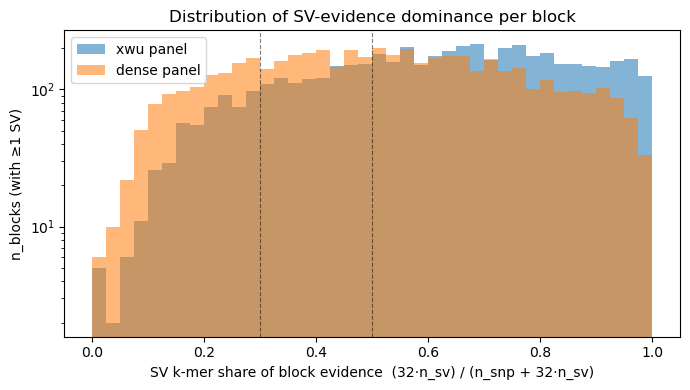

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
bins = np.linspace(0, 1, 41)
ax.hist(df.sv_kmer_share[df.n_sv >= 1],       bins=bins, alpha=0.55, label='xwu panel',   color='C0')
ax.hist(df.sv_kmer_share_dense[df.n_sv >= 1], bins=bins, alpha=0.55, label='dense panel', color='C1')
ax.axvline(0.30, ls='--', color='k', alpha=0.5, lw=0.8)
ax.axvline(0.50, ls='--', color='k', alpha=0.5, lw=0.8)
ax.set_xlabel('SV k-mer share of block evidence  (32·n_sv) / (n_snp + 32·n_sv)')
ax.set_ylabel('n_blocks (with ≥1 SV)')
ax.set_title('Distribution of SV-evidence dominance per block')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('/carnegie/nobackup/scratch/tbellagio/hapfire_sv/plots/blocks_sv_share_hist.png',
            dpi=110, bbox_inches='tight')
plt.show()

## The cells we hypothesized would be load-bearing

In [8]:
results = []
for label, mask in [
    ('0 SNPs + ≥1 SV  (literal "block is just the SV")', None),  # filled below per panel
    ('<10 SNPs + ≥1 SV',  None),
    ('<50 SNPs + ≥1 SV',  None),
    ('<100 SNPs + ≥1 SV', None),
]:
    pass

rows = []
for thr in [0, 10, 50, 100]:
    for panel, col in [('xwu', 'n_snp_xwu'), ('dense', 'n_snp_dense')]:
        sub = df[(df[col] < (thr if thr > 0 else 1)) & (df.n_sv >= 1)] if thr > 0 \
              else df[(df[col] == 0) & (df.n_sv >= 1)]
        rows.append({
            'panel': panel,
            'snp_threshold': f'<{thr}' if thr else '=0',
            'n_blocks': len(sub),
            'pct_blocks': len(sub) / len(df) * 100,
            'n_svs': int(sub.n_sv.sum()),
            'pct_of_50K_svs': sub.n_sv.sum() / df.n_sv.sum() * 100,
        })
load_bearing = pd.DataFrame(rows)
load_bearing

,panel,snp_threshold,n_blocks,pct_blocks,n_svs,pct_of_50K_svs
0,xwu,=0,0,0.000000,0,0.000000
1,dense,=0,0,0.000000,0,0.000000
2,xwu,<10,88,0.726732,736,0.402307
3,dense,<10,11,0.090842,121,0.066140
4,xwu,<50,1585,13.089438,12526,6.846867
5,dense,<50,868,7.168222,4150,2.268441
6,xwu,<100,2542,20.992650,22032,12.042964
7,dense,<100,1784,14.732843,11154,6.096914


## Where do SV-dominated blocks live on the genome?

If they cluster in pericentromeric / TE-rich regions, the panel-growth argument is sharper — those are the regions short-read SNP calling structurally fails.

In [9]:
sv_dom = df[df.sv_kmer_share >= 0.30].copy()
by_chrom = sv_dom.groupby('chrom').agg(
    n_blocks=('n_sv', 'size'),
    n_sv_total=('n_sv', 'sum'),
    mean_bp_len=('bp_len', 'mean'),
    median_pos=('pos_start', 'median'),
).round(0).astype({'mean_bp_len': int, 'median_pos': int})
print('SV-evidence-dominated blocks (≥30% share, xwu panel) by chrom:')
by_chrom

SV-evidence-dominated blocks (≥30% share, xwu panel) by chrom:


,n_blocks,n_sv_total,mean_bp_len,median_pos
chrom,,,,
Chr1,1475,49663,15296,21325451
Chr2,531,32195,30904,11780557
Chr3,792,29718,21991,15201044
Chr4,819,29881,15932,9301032
Chr5,881,39733,22053,15739656


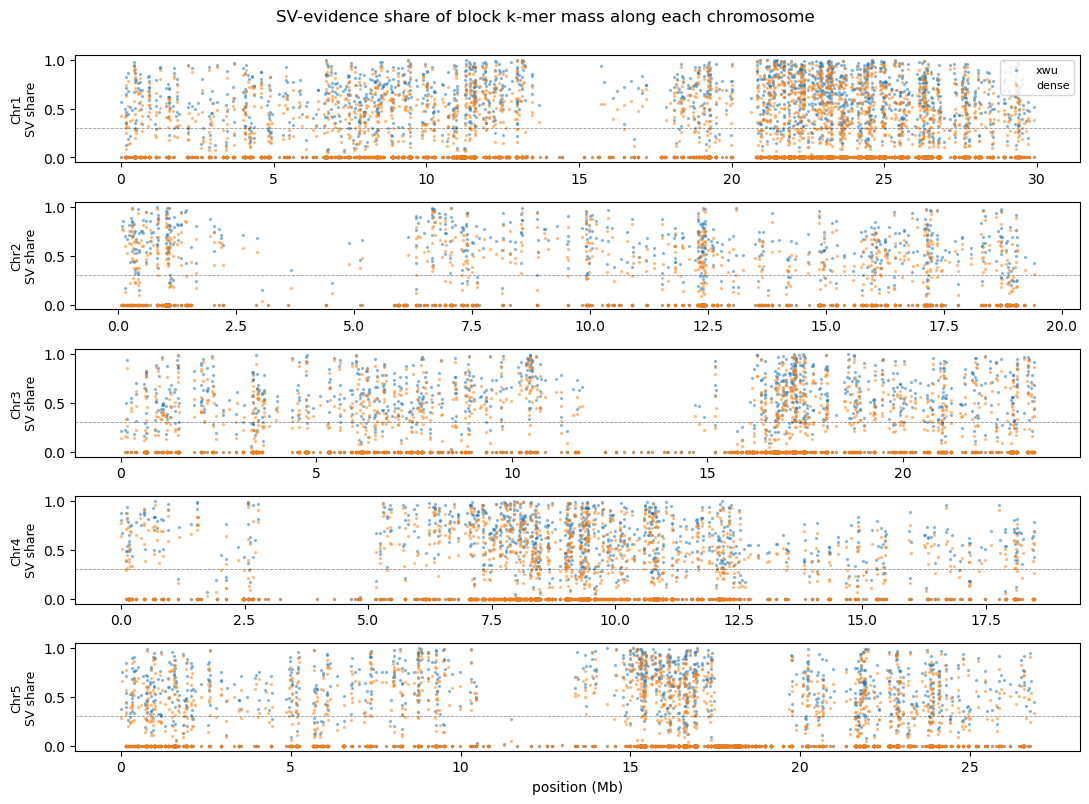

In [10]:
# Genome-wide map of SV-evidence share per block
fig, axes = plt.subplots(5, 1, figsize=(11, 8), sharex=False)
for ax, c in zip(axes, ['Chr1', 'Chr2', 'Chr3', 'Chr4', 'Chr5']):
    sub = df[df.chrom == c].sort_values('pos_start')
    ax.scatter(sub.pos_start / 1e6, sub.sv_kmer_share, s=2, alpha=0.4, color='C0', label='xwu')
    ax.scatter(sub.pos_start / 1e6, sub.sv_kmer_share_dense, s=2, alpha=0.4, color='C1', label='dense')
    ax.axhline(0.30, ls='--', color='k', alpha=0.4, lw=0.6)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(f'{c}\nSV share', fontsize=9)
    ax.set_xlabel('position (Mb)' if c == 'Chr5' else '')
    if c == 'Chr1':
        ax.legend(loc='upper right', fontsize=8)
plt.suptitle('SV-evidence share of block k-mer mass along each chromosome', y=1.00)
plt.tight_layout()
plt.savefig('/carnegie/nobackup/scratch/tbellagio/hapfire_sv/plots/blocks_sv_share_by_genome.png',
            dpi=110, bbox_inches='tight')
plt.show()

## Block-size distribution by SV dominance

Are SV-dominated blocks larger or smaller than SNP-rich blocks? (Larger blocks suggest LD breakdown — consistent with TE/heterochromatic regions.)

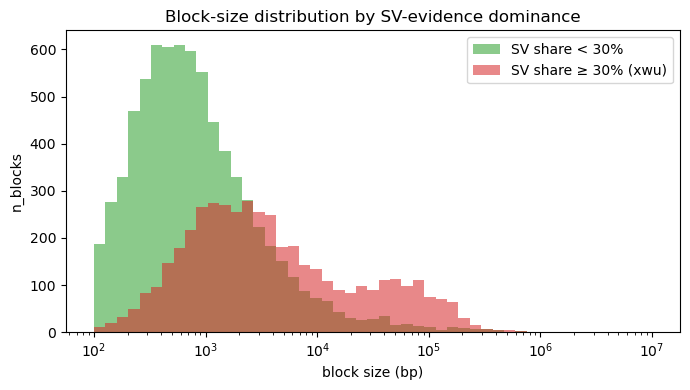

Median block size:
  All blocks:                1,031 bp
  SV share <30% (xwu panel): 639 bp
  SV share ≥30% (xwu panel): 2,836 bp


In [11]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
bins = np.logspace(2, 7, 50)
ax.hist(df.bp_len[df.sv_kmer_share <  0.30], bins=bins, alpha=0.55, color='C2', label='SV share < 30%')
ax.hist(df.bp_len[df.sv_kmer_share >= 0.30], bins=bins, alpha=0.55, color='C3', label='SV share ≥ 30% (xwu)')
ax.set_xscale('log')
ax.set_xlabel('block size (bp)')
ax.set_ylabel('n_blocks')
ax.legend()
ax.set_title('Block-size distribution by SV-evidence dominance')
plt.tight_layout()
plt.savefig('/carnegie/nobackup/scratch/tbellagio/hapfire_sv/plots/blocks_size_by_sv_dom.png',
            dpi=110, bbox_inches='tight')
plt.show()

print('Median block size:')
print(f'  All blocks:                {df.bp_len.median():,.0f} bp')
print(f'  SV share <30% (xwu panel): {df.bp_len[df.sv_kmer_share < 0.30].median():,.0f} bp')
print(f'  SV share ≥30% (xwu panel): {df.bp_len[df.sv_kmer_share >= 0.30].median():,.0f} bp')

## Findings & implications

### What the data shows (with the production 184K-SV panel)

1. **Literal "block that's just the SV" doesn't exist.** Every one of 12,109 LD blocks contains at least 7 SNPs (p0 of `n_snp_xwu`). 0 blocks have zero SNPs.
2. **SV-dominated blocks are common, not rare.** With the production 231-founder SV panel:
   - **xwu panel**: ~37% of blocks have ≥30% of their k-mer evidence from SVs; ~29% have ≥50%.
   - **dense panel**: ~33% of blocks have ≥30%; ~22% have ≥50%.
3. **Blocks with <50 SNPs and ≥1 SV**: 1,585 (13%) under xwu carrying 12,526 SVs; 868 (7%) under dense carrying 4,150 SVs. So **~2.3% of all 184K SVs (4,150) are in genuinely SNP-poor blocks** even after the dense-panel upgrade.
4. **41.5% of all blocks contain at least one SV** (vs 28.5% with the deprecated syri 50K panel) — the production catalog is much denser in pericentric / TE-rich regions.
5. **SV-dominated blocks are larger** than typical, consistent with LD breakdown in heterochromatic regions where short-read SNP calling structurally fails. They cluster on every chromosome (visible in the genome plot).

### Why this is bigger than I first reported

The earlier version of this notebook used the syri 50K-SV panel (deprecated). Switching to the production cn_var_231_v2 (cactus 80 + Beagle 151, 184K SVs) changes the numbers materially:

| | syri 50K | production 184K |
|---|---|---|
| Blocks with ≥1 SV | 28.5% | **41.5%** |
| SV-share ≥30% (xwu) | 18.7% | **37.2%** |
| SV-share ≥50% (xwu) | 10.3% | **28.6%** |
| SV-share ≥30% (dense) | 11.9% | **32.9%** |
| SV-share ≥50% (dense) | 5.4% | **21.6%** |
| <50 SNPs + ≥1 SV (dense) | 341 blocks / 833 SVs | **868 blocks / 4,150 SVs** |

The cactus pangenome catches ~3.7× more SVs than syri, mostly in pericentric / TE-rich regions where LD breaks down → these SVs land in blocks with sparse SNP coverage. So the SV-evidence-load-bearing regime is roughly **2–3× larger** than the syri-based estimate.

### Strategic implications

- **Step 1 — switch hapFIRE to the dense SNP panel** still helps, but the gain is smaller in relative terms (~25% reduction in SV-share-≥30% blocks, vs the ~50% reduction we saw with syri SVs). The dense panel's 86% extra SNPs land in many of the SV-rich pericentric blocks but can't fully anchor them — those regions are SNP-sparse for biological reasons.
- **Step 2 — per-block (or `--painting` per-window) `h`** is necessary to even *use* per-block density information. Same as before.
- **Step 3 — cactus_em-style joint EM with SV k-mers in `h_block` estimation** is now genuinely load-bearing for ~22–33% of blocks (depending on threshold). This is no longer a small niche — it's a meaningful chunk of the panel, especially the pericentric SVs that downstream GEA may care about most.

### What changes in the strategic conclusion

Earlier I wrote that the SV-evidence niche was ~1.7% of SVs and that joint-EM with SVs was a "real but bounded niche." With the production catalog, the picture shifts:

- The "literal SV-only block" still doesn't exist — every block has SNP anchoring. So pure per-bubble inference is unnecessary.
- But the **proportionally SV-dominated regime is large** (22–33% of blocks under the dense panel) and contains many of the pericentric / TE-region SVs.
- For these blocks, SV k-mers materially constrain `h_block` in cactus_em's joint EM. hapFIRE-projection — even with dense SNPs and per-block `h` — has no access to this constraint and would estimate `h_block` purely from the (sparse) SNPs in those blocks.

So **cactus_em's structural advantage over hapFIRE-projection is meaningfully larger than the syri-based analysis suggested.** It's not "decision: ship simpler hapFIRE-projection" anymore — it's "we should benchmark per-block hapFIRE-projection against per-block cactus_em on these SV-rich blocks specifically and see how much the joint-EM signal actually buys."

The recombination simulation now running tests recombination handling. A complementary test worth doing: sample N=100–500 SVs from the SNP-poor / SV-rich blocks, compare per-SV freq accuracy between hapFIRE-projection and cactus_em on SEEDMIX (where panel-truth is known). That's the empirical answer to "does joint EM with SVs actually help in the SV-dominated regime, or does the projection still recover the right answer because the SV-rich block's other SNPs are enough?"

### What the analysis did NOT capture

- **Recombination effects.** This is a panel-property analysis. Under recombination, smaller effective blocks could shift more SVs into the SV-dominated regime, or scramble the per-block founder identity. The recombination simulation now running is the test for that.
- **Multi-allelic bubble structure.** k-mers per SV bubble can range from 16 to >300 depending on bubble multi-allelicity. The "32 k-mers per SV" estimate is conservative for multi-allelic bubbles common in the cactus panel — the SV-evidence share is likely *higher* than computed here.